In [ ]:
from time import perf_counter

import numpy as np
import pandas as pd
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

from tqdm import tqdm

# Internal imports
from rate import q_approx_full

In [2]:
# set plot style
%matplotlib widget
plt.style.use('plot_style.txt')

In [20]:
def conveyance_efficiency(Q, W, S, n, cl, aq):

    def f(h, Q, W, S, n):
        R = h * W / (2 * h + W)
        u = R**(2/3) * S**0.2 / n
        return Q - W * h * u
    
    stage = fsolve(f, 0.1, args=(Q, W, S, n))[0]
    q = q_approx_full(stage, cl['cond'], cl['th'], aq['cond'], aq['scale'],
                      aq['shape'], 'vGM')

    return W * q / Q, stage

In [69]:
cl = {
    'cond': 1e-6,
    'th': 0.1
}
aq = {
    'cond': 1e-5,
    'scale': 0.1,
    'shape': 3.4
}

Q = 50 # m^3/s
n = 0.01
S = 1e-3

In [70]:
W = np.linspace(0.1, 6)
eff, stage = np.array([conveyance_efficiency(Q, v, S, n, cl, aq) for v in W]).T

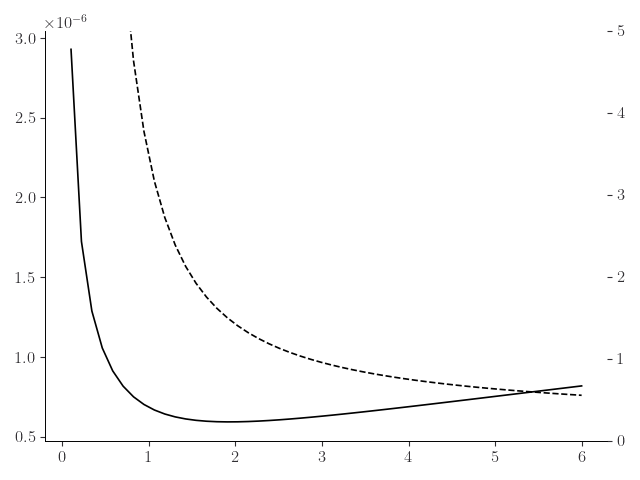

In [71]:
fig, ax = plt.subplots()

ax.plot(W, eff, ls='-', c='k')


ax2 = ax.twinx()
ax2.plot(W, stage, ls='--', c='k')
ax2.set_ylim(ymin=0, ymax=5)

plt.tight_layout()